In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import zarr
from scipy.optimize import curve_fit
import os
import sys
from pathlib import Path

sys.path.append(os.path.abspath(".."))

from libs import fit_model as fm
from libs import cal_vel as cv
from libs import displacement as dpm

plt.style.use('../libs/my_style.mplstyle')
style_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
root = Path('/Volumes/My Passport/Sasaki/MTsingleBeads')

path0 = root / "20260121" / 'exp_crop1'
path1 = root / "20260121" / 'beads_trans_crop_crop'
path2 = root / "20260122" / "exp"
path3 = root / "20260122" / 'exp001'

path_list = [path0, path1, path2, path3]

particles = []
bgs = []

for input_dir in path_list:
    particle= xr.open_zarr(input_dir / "local_polar_w.zarr")
    bg = xr.open_zarr(input_dir / "local_polar_bg.zarr")
    particles.append(particle)
    bgs.append(bg)

/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_65933/2260844312.py:14: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  particle= xr.open_zarr(input_dir / "local_polar_w.zarr")
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_65933/2260844312.py:15: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this exist

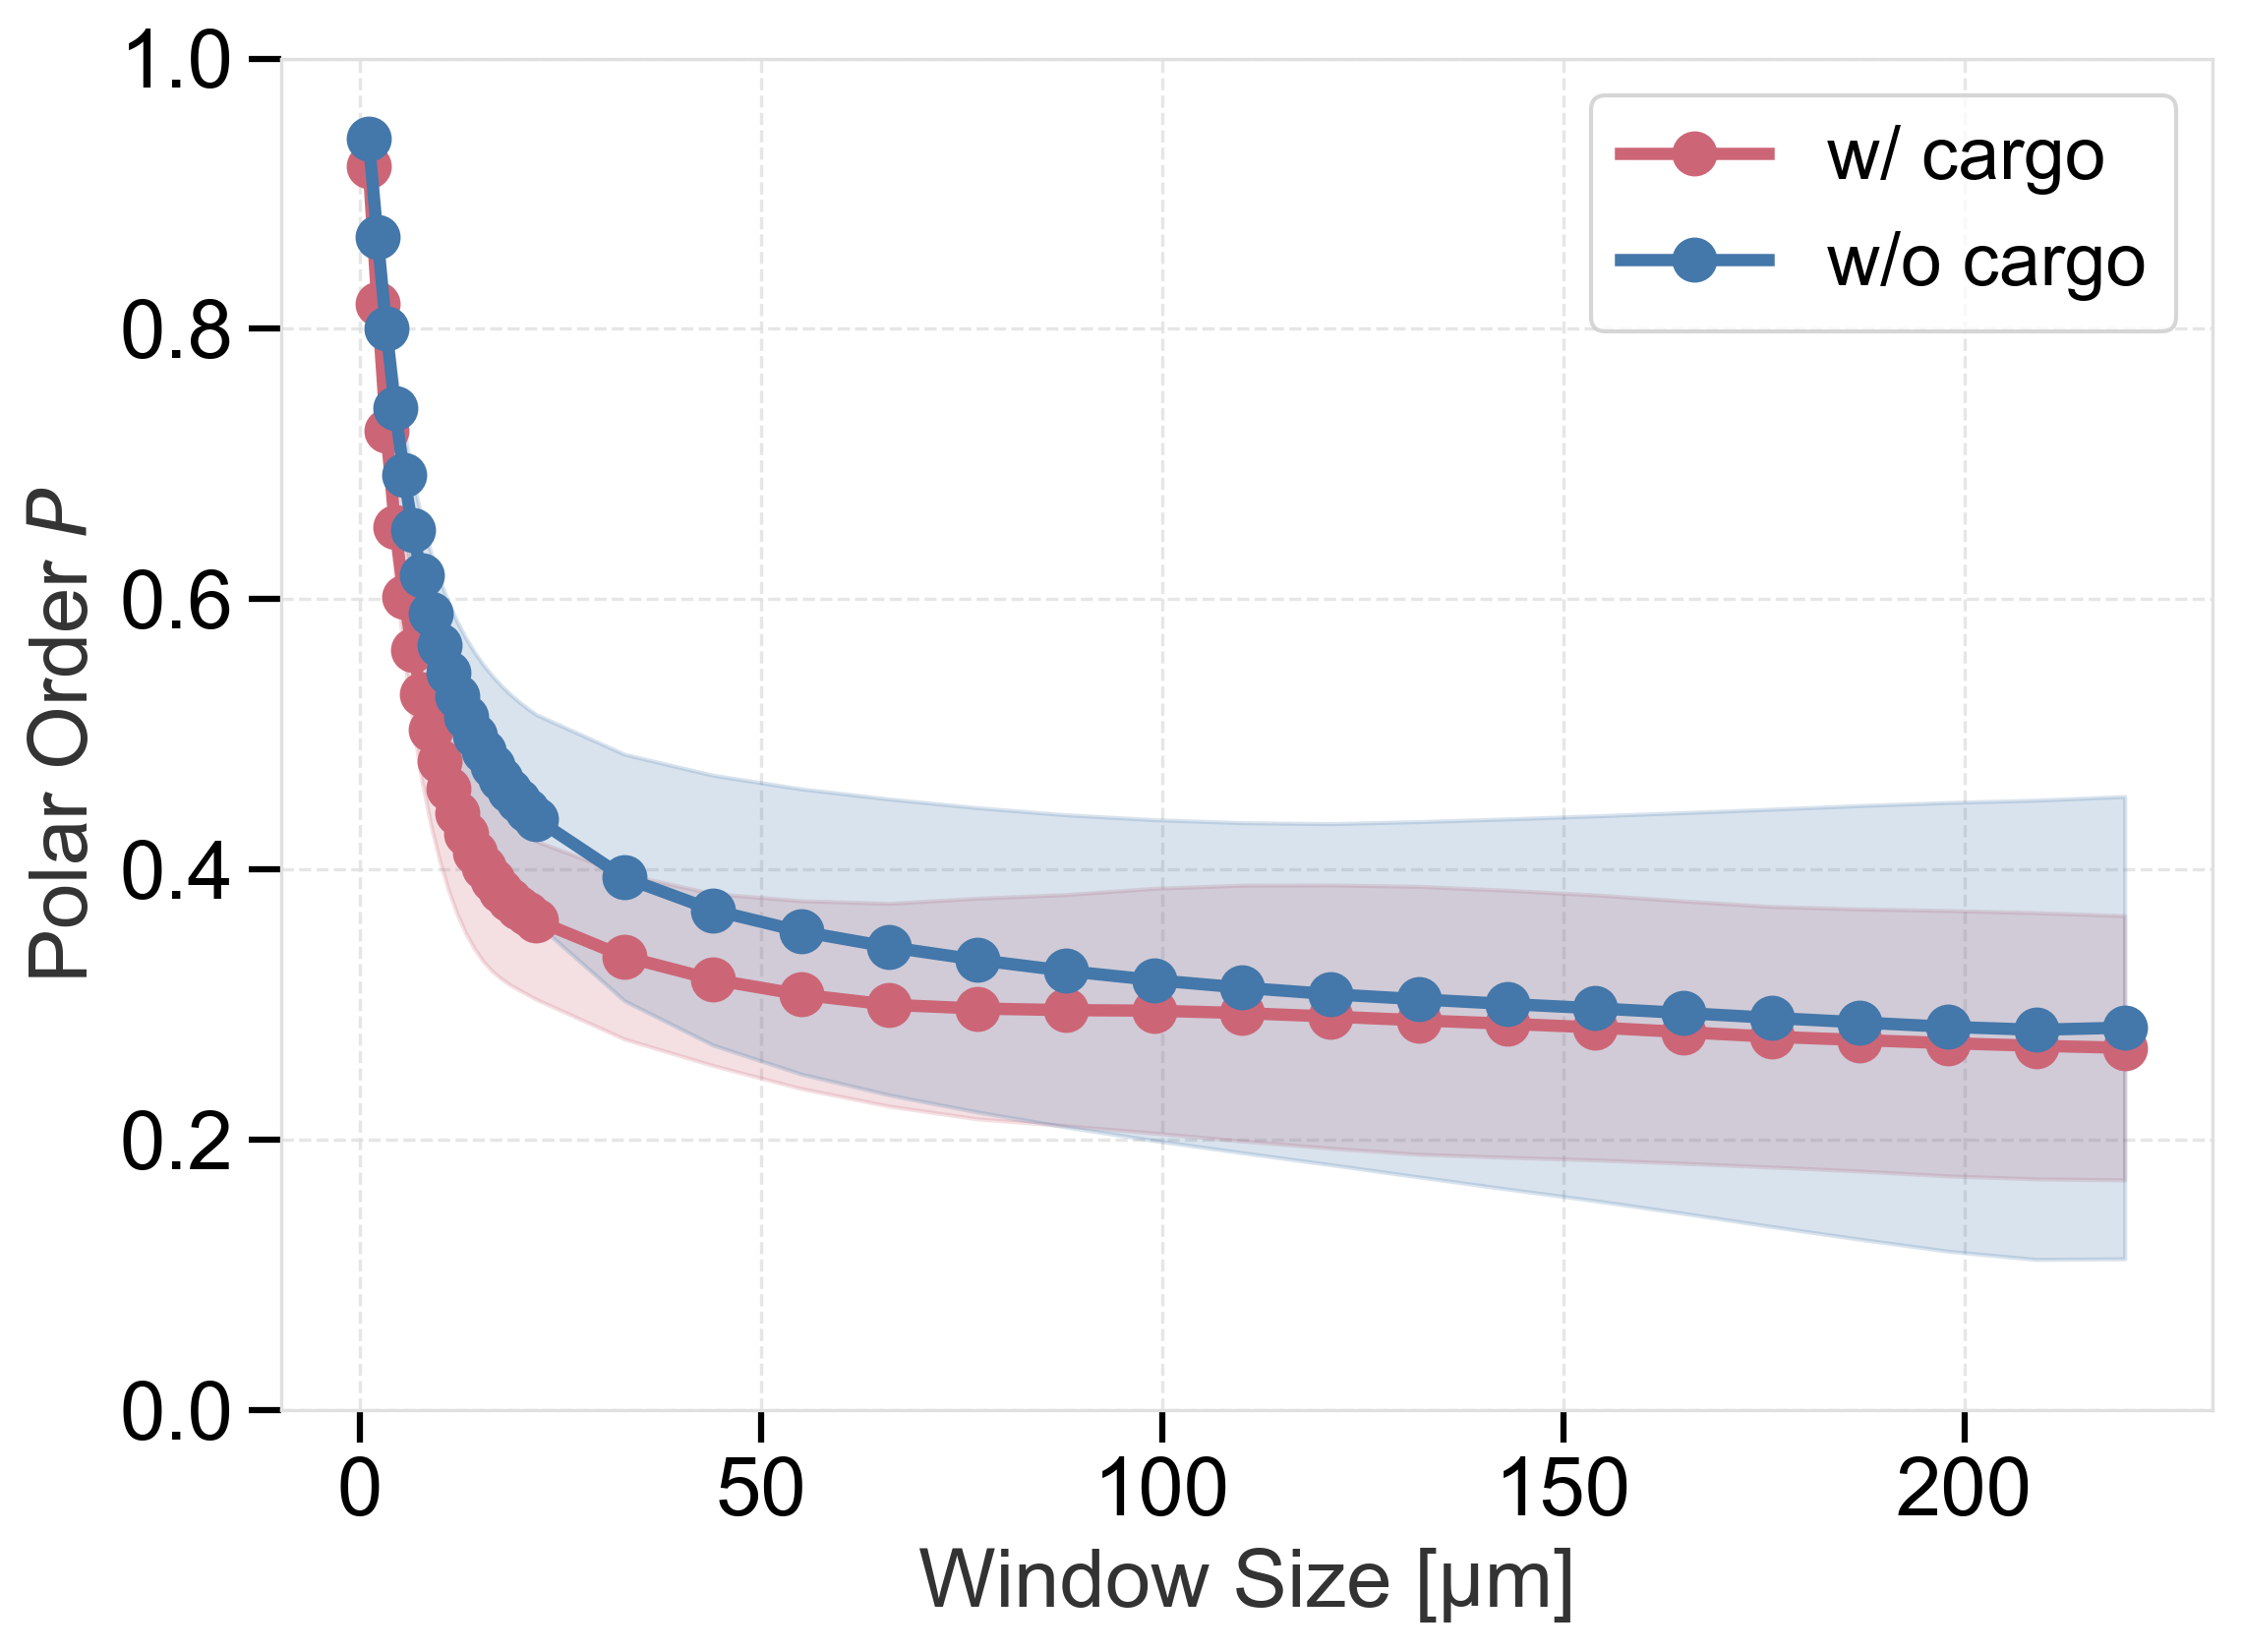

<Figure size 2400x1800 with 0 Axes>

In [6]:
import matplotlib.pyplot as plt
import numpy as np

scale = 0.11

plt.figure()

# --- 1. 統計量の計算 (w/ cargo) ---
# 粒子ごと、フレームごとの平均をとる前の「ばらつき」を保持

p_means = []
bg_means = []

for particle in particles:
    mean = particle.polar_order.mean(dim=['frame', 'particle'])
    p_means.append(mean)
    #p_std  = particle.polar_order.std(dim=['frame', 'particle']) # 標準偏差

p_array = np.array(p_means)
p_mean = np.mean(p_array, axis=0)
p_std = np.std(p_array, axis=0)

# --- 2. 統計量の計算 (w/o cargo) ---
for bg in bgs:
    mean = bg.polar_order.mean(dim=['frame'])
    bg_means.append(mean)
    #bg_std  = bg.polar_order.std(dim=['frame'])

bg_array = np.array(bg_means)
bg_mean = np.mean(bg_array, axis=0)
bg_std = np.std(bg_array, axis=0)

# --- 3. プロット ---

# ウィンドウサイズ（x軸）の取得
x_coords = mean['window size'].values * scale

# w/ cargo
plt.plot(x_coords, p_mean, color='#CC6677', marker='o', label='w/ cargo')
plt.fill_between(x_coords, p_mean - p_std, p_mean + p_std, color='#CC6677', alpha=0.2)

# w/o cargo
plt.plot(x_coords, bg_mean, color='#4477AA', marker='o', label='w/o cargo')
plt.fill_between(x_coords, bg_mean - bg_std, bg_mean + bg_std, color='#4477AA', alpha=0.2)

plt.legend()
plt.xlabel("Window Size [\u03bcm]")
plt.ylabel("Polar Order $P$")
plt.ylim(0, 1)
plt.show()

fig_dir = Path("/Users/sasakinozomu/code/MTCargo_analysis/notebooks/figures")

plt.savefig(fig_dir / "local_polar.png")
plt.savefig(fig_dir / "local_polar.pdf")
